## Prediction of Customer Churn Pbobability

The notebook in fourth entry to competition I started with Basics to start with, before I test pipelione and ensemble

In [1]:
# =============================================================================
# 1. Import Libraries
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Set visual style
sns.set(style="whitegrid")

In [2]:
# =============================================================================
# 2. Data Loading 
# =============================================================================
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

print("Completed Loading Data ...")

# Basic Info and Missing Values
# Descriptive Statistics
stats = train_df.describe()

print("Basic Info:\n", train_df.info())
print("\nMissing Values:\n", train_df.isnull().sum())
print("\nDescriptive Stats:\n", stats)


Completed Loading Data ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object

/tmp/ipykernel_17/1690813596.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_df, palette='viridis', legend=False)


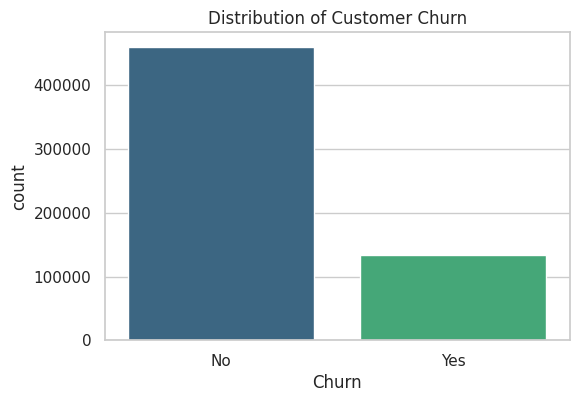

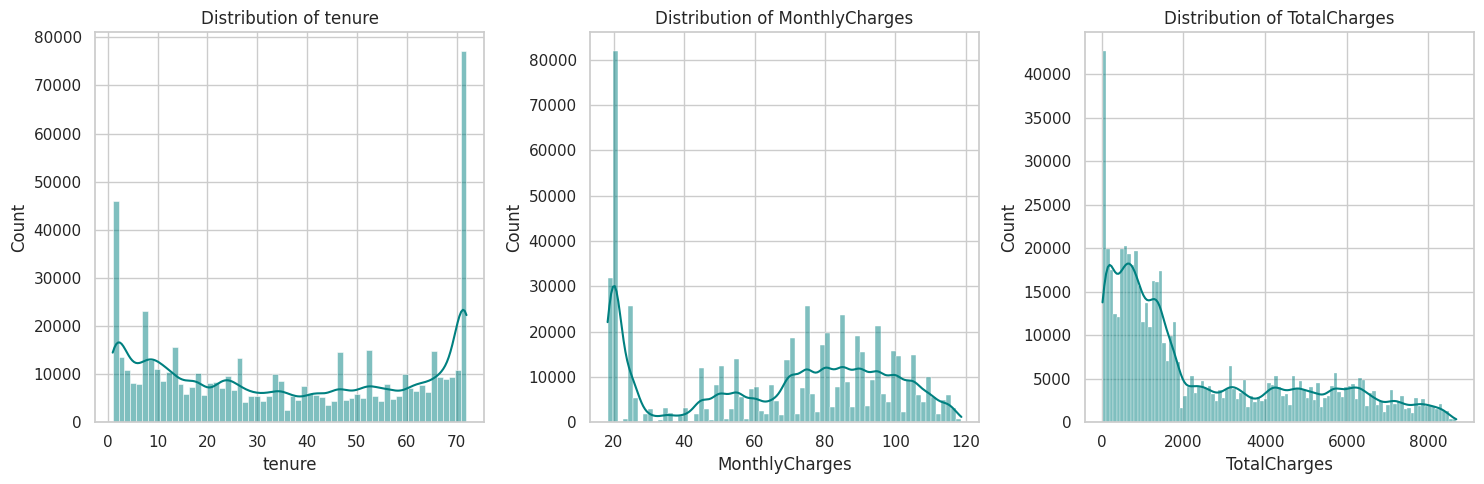

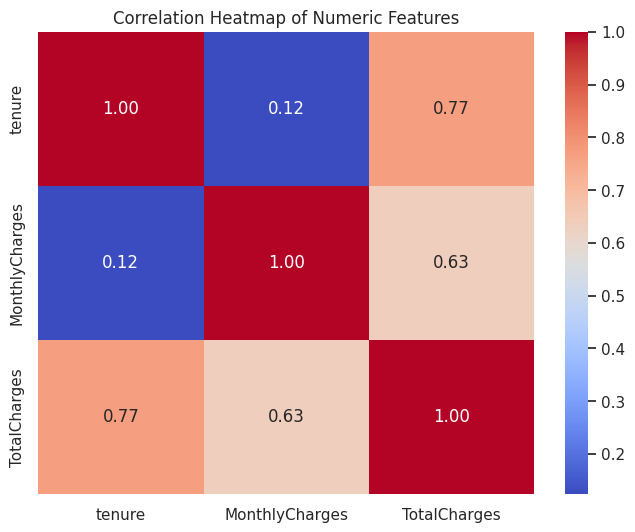

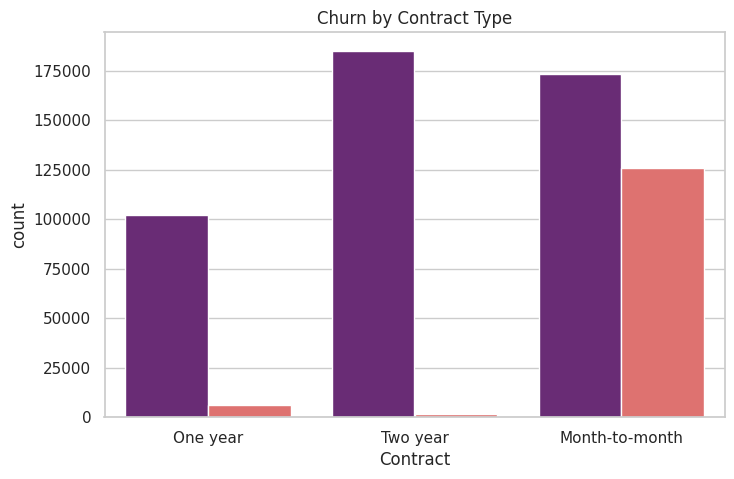

In [3]:
# =============================================================================
# 3. Basic Exploratory Data Analytics
# =============================================================================

# Clean TotalCharges for analysis
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(train_df['TotalCharges'].median())

# Distribution of Target Variable (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=train_df, palette='viridis', legend=False)
plt.title('Distribution of Customer Churn')
plt.savefig('churn_distribution.png')

# Numeric Features Distribution
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(train_df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('numeric_distributions.png')

# Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation = train_df[numeric_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig('correlation_heatmap.png')

# Churn by Contract Type (Categorical Analysis)
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=train_df, palette='magma', legend=False)
plt.title('Churn by Contract Type')
plt.savefig('churn_by_contract.png')


In [4]:
# =============================================================================
# 3. Preprocessing and Cleaning
# =============================================================================
def preprocess_data(df):
    # Convert TotalCharges to numeric, handling empty strings
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
    return df

train_df = preprocess_data(train_df)
test_df = preprocess_data(test_df)

train_df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [5]:
# =============================================================================
# 4. Label Encoding for Categorical Columns
# =============================================================================
le = LabelEncoder()
cat_features = train_df.select_dtypes(include=['object']).columns.drop(['Churn']) if 'Churn' in train_df.columns else []

for col in cat_features:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

# Encode target
train_df['Churn'] = train_df['Churn'].map({'Yes': 1, 'No': 0})

In [6]:
# =============================================================================
# 5. Train/Test Split
# =============================================================================
X = train_df.drop(['id', 'Churn'], axis=1)
y = train_df['Churn']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# =============================================================================
# 6. Modeling
# =============================================================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

/tmp/ipykernel_17/3888508567.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


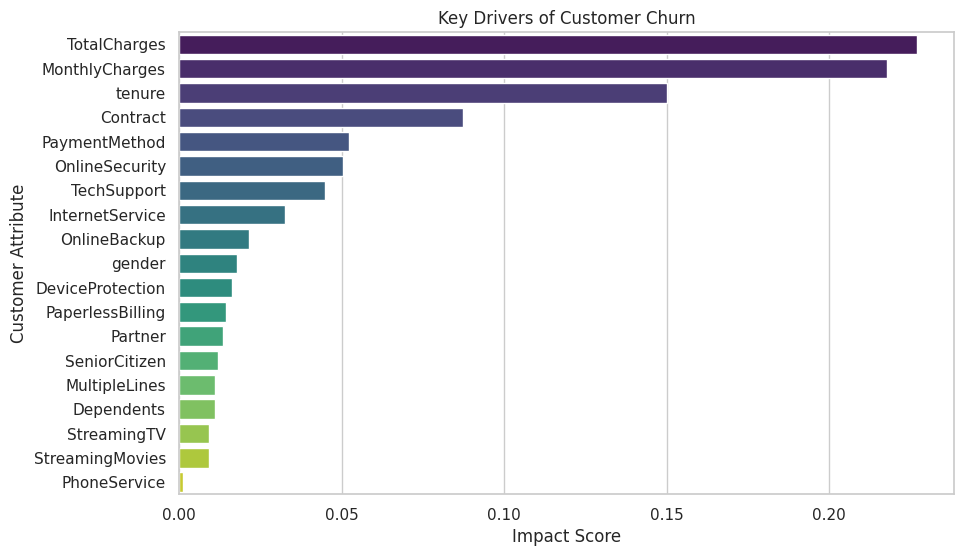

In [8]:
# =============================================================================
# 7. FEATURE IMPORTANCE VISUALIZATION
# =============================================================================
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Drivers of Customer Churn')
plt.xlabel('Impact Score')
plt.ylabel('Customer Attribute')
plt.show()

In [9]:
# =============================================================================
# 7. Final Predictions
# =============================================================================
test_ids = test_df['id']
X_test_final = test_df.drop(['id'], axis=1)
predictions = rf_model.predict(X_test_final)

# predict_proba returns [prob_of_0, prob_of_1]
probabilities = rf_model.predict_proba(X_test_final)

# 2. Extract the probability for 'Churn = Yes' (index 1)
churn_probability = probabilities[:, 1]

In [10]:
# =============================================================================
# 9. Submission
# =============================================================================
TARGET = 'Churn'

submission = pd.DataFrame({
    'id'  : test_ids,
    TARGET: churn_probability,
})

submission.to_csv("submission.csv", index=False)

print("\nSubmission Created Successfully.")

submission.head(20)



Submission Created Successfully.


,id,Churn
0,594194,0.05
1,594195,0.00
2,594196,0.04
3,594197,0.00
4,594198,0.36
5,594199,0.20
6,594200,0.97
7,594201,0.00
8,594202,0.02
9,594203,0.31
